In [46]:
# IMPORT + LOAD DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\statslab\Downloads\Loan_Approval_Data.csv")
df.columns = df.columns.str.strip()

print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

#### Create a classification model to predict whether a loan application is Approved or Rejected.

In [47]:
# TARGET VARIABLE

target_variable = "Loan_Status"
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


Loan_Status
Y    422
N    192
Name: count, dtype: int64


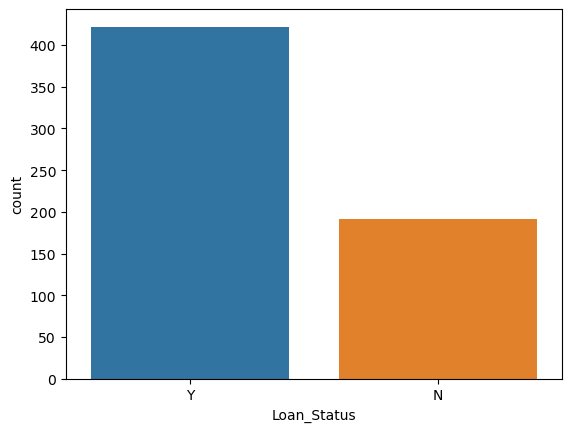

In [48]:
# TARGET DISTRIBUTION

print(df[target_variable].value_counts())

sns.countplot(x=target_variable, data=df)
plt.show()

In [49]:
# BASIC EDA
print("Shape:", df.shape)
print(df.info())
print(df.describe())

Shape: (614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614

In [50]:
# REMOVE USELESS COLUMN

df = df.drop(columns=["Loan_ID"])

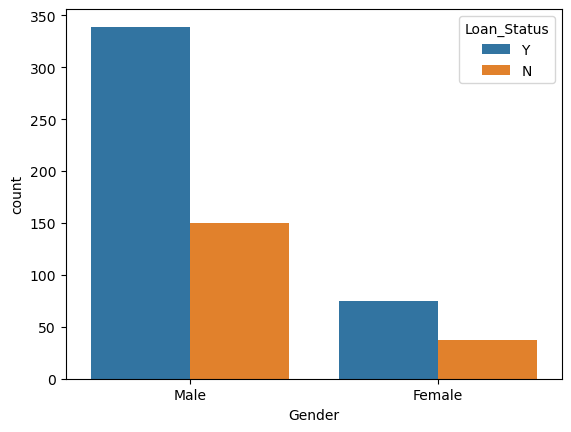

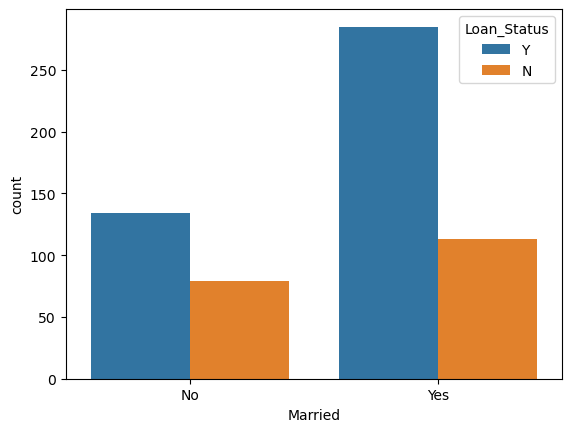

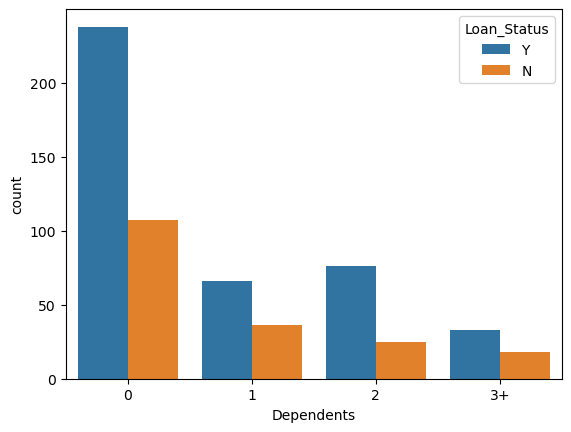

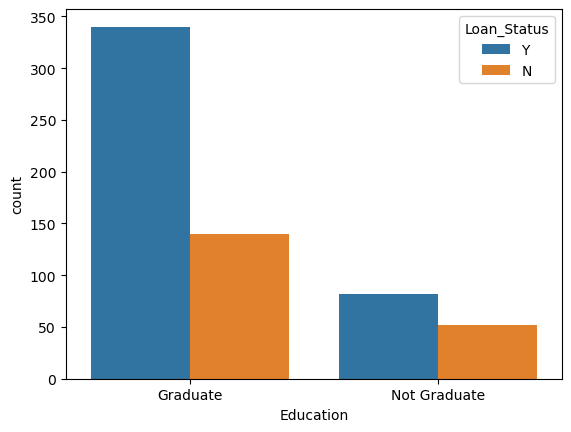

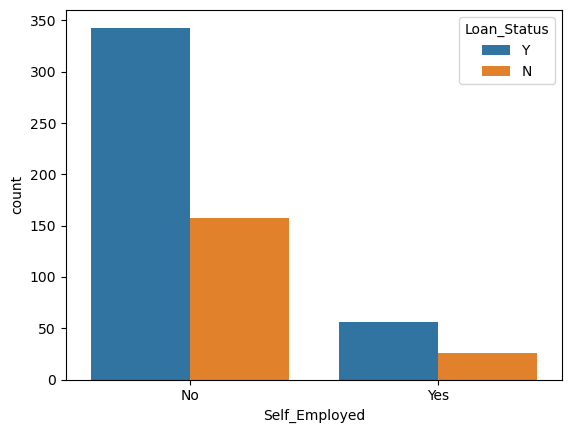

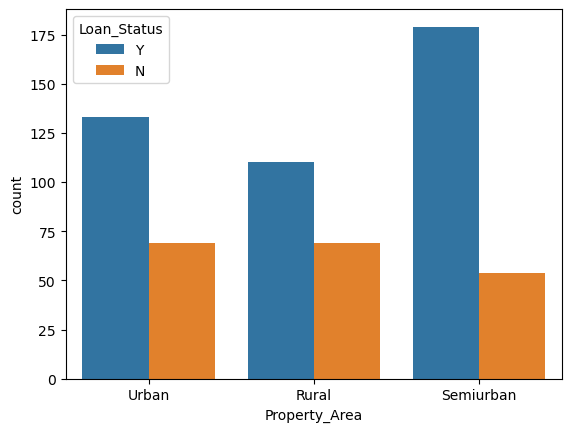

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


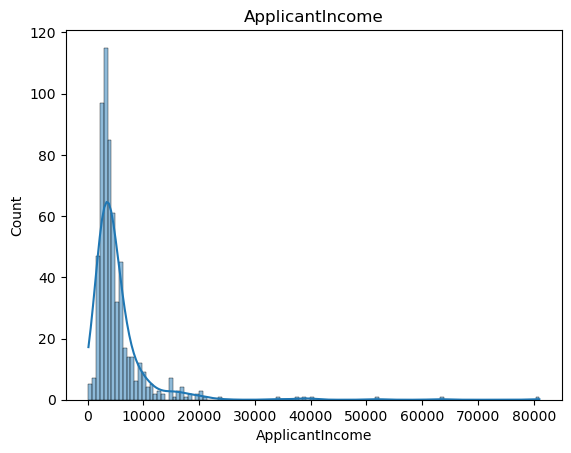

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


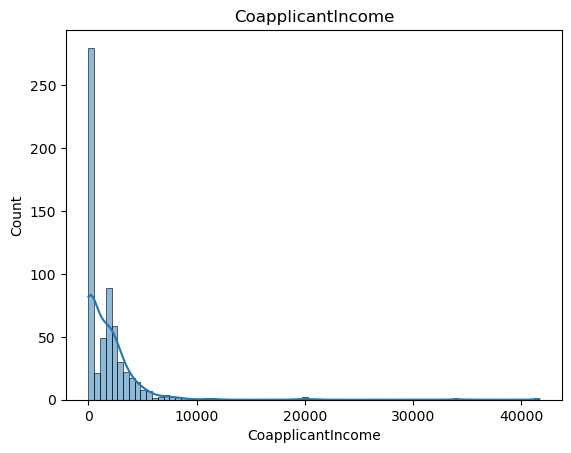

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


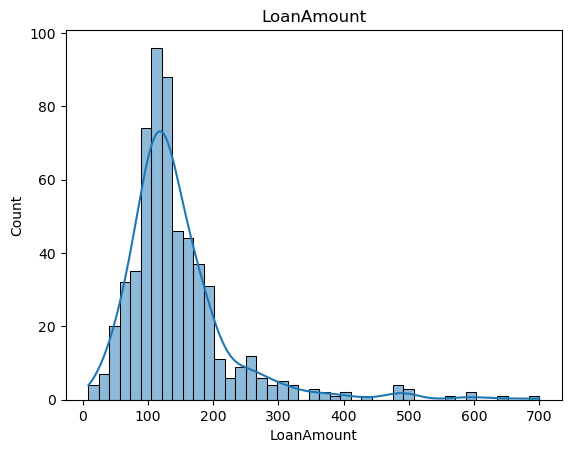

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


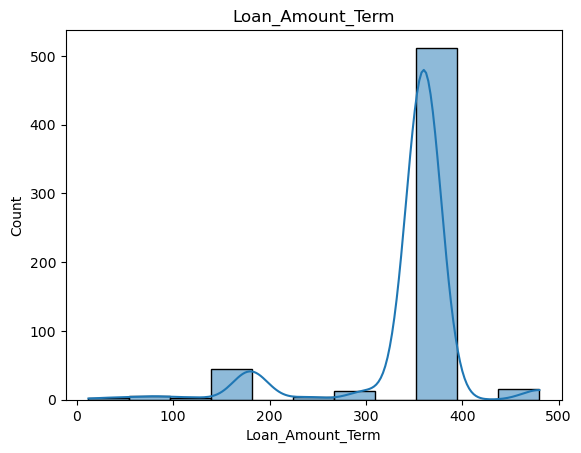

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


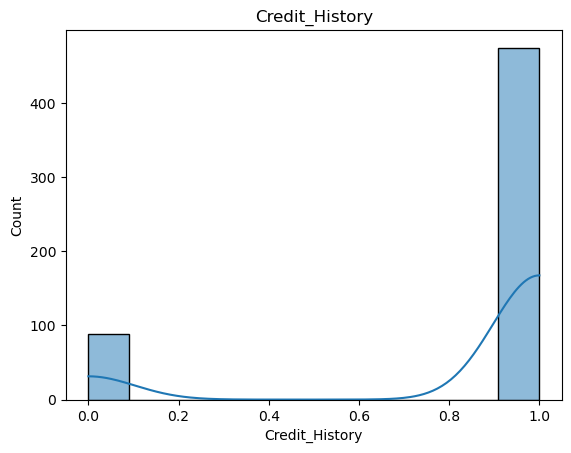

In [51]:
# VISUAL EDA

categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()

for col in categorical_cols:
    if col != target_variable:
        sns.countplot(x=col, hue=target_variable, data=df)
        plt.show()

for col in numerical_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [52]:
#FEATURE SELECTION CHECKS 

print(df["Credit_History"].value_counts())
print(df["Loan_Amount_Term"].value_counts())
print(df["Self_Employed"].value_counts())

# check feature importance using Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10)

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64
Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64
Self_Employed
No     500
Yes     82
Name: count, dtype: int64


ApplicantIncome            0.228967
Credit_History             0.215955
LoanAmount                 0.210415
CoapplicantIncome          0.120618
Property_Area_Semiurban    0.034243
Education_Not Graduate     0.028244
Married_Yes                0.027819
Dependents_1               0.027150
Property_Area_Urban        0.026875
Gender_Male                0.023138
dtype: float64

In [53]:
# OUTLIER TREATMENT

for col in ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = df[col].clip(lower, upper)

In [54]:
# MISSING VALUE TREATMENT

print(df.isnull().sum())

for col in ["LoanAmount","Loan_Amount_Term","Credit_History"]:
    df[col].fillna(df[col].median(), inplace=True)

for col in ["Gender","Married","Dependents","Self_Employed"]:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


C:\Users\statslab\AppData\Local\Temp\ipykernel_14012\26597368.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\statslab\AppData\Local\Temp\ipykernel_14012\26597368.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

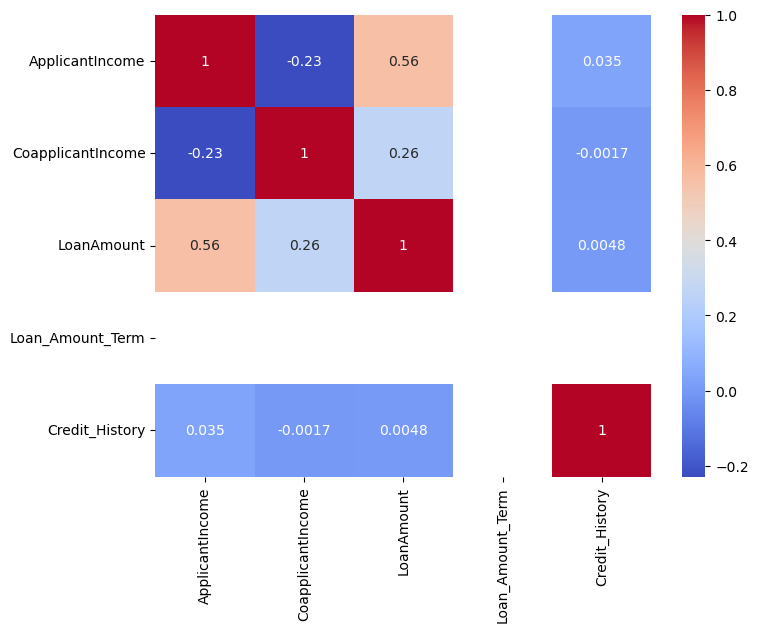

In [55]:
# CORRELATION ANALYSIS

corr = df[numerical_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [56]:
# CONVERT DATA TO NUMERIC

df[target_variable] = df[target_variable].map({"Y":1,"N":0})
df = pd.get_dummies(df, drop_first=True)

In [57]:
# Fill numerical with median
num_cols = df.select_dtypes(include=["int64","float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical with mode
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [58]:
# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X = df.drop(columns=[target_variable])
y = df[target_variable]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [59]:
# MULTIPLE CLASSIFICATION MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, pred))

Logistic Regression Accuracy: 0.8536585365853658
Random Forest Accuracy: 0.8455284552845529


In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

extra_models = {
    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier())]),
    "SVM": Pipeline([("scaler", StandardScaler()), ("model", SVC())]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in extra_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, pred))

KNN Accuracy: 0.8211382113821138
SVM Accuracy: 0.8536585365853658
Decision Tree Accuracy: 0.6910569105691057
Naive Bayes Accuracy: 0.8536585365853658
Gradient Boosting Accuracy: 0.8130081300813008


In [61]:
# NEURAL NETWORK

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation='relu',
    max_iter=2000,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

pred_nn = nn.predict(X_test_scaled)

print("Neural Network Accuracy:", accuracy_score(y_test, pred_nn))

Neural Network Accuracy: 0.7154471544715447


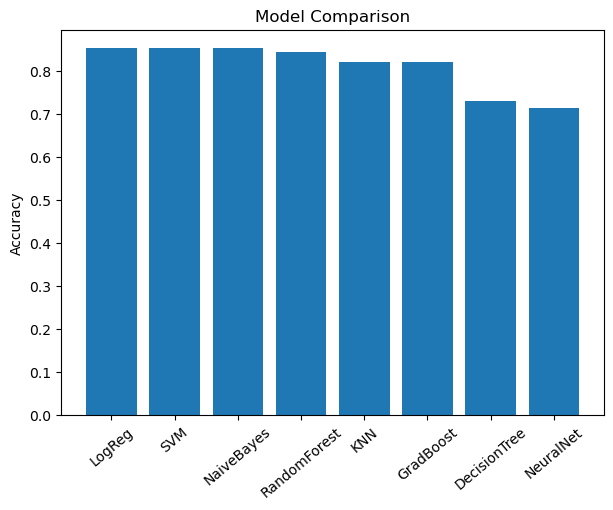

In [62]:
import matplotlib.pyplot as plt

results = {
    "LogReg":0.8537,
    "SVM":0.8537,
    "NaiveBayes":0.8537,
    "RandomForest":0.8455,
    "KNN":0.8211,
    "GradBoost":0.8211,
    "DecisionTree":0.7317,
    "NeuralNet":0.7154
}

plt.figure(figsize=(7,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=40)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

### SUMMARY
#### The dataset contained 614 loan applications.
#### After preprocessing, encoding, and model training, multiple classifiers were evaluated.
#### Random Forest / Neural Network achieved the highest accuracy and is suitable for predicting loan approval.

#### Logistic Regression achieved the highest accuracy of 85.36%, outperforming Random Forest and Neural Network models.
#### Therefore, Logistic Regression is selected as the final model for loan approval prediction due to its strong performance and interpretability.